# 03 Fitted Curves

**Book:** *Fixed Income Relative Value Analysis (2nd ed.)*  
**Focus:** Chapter 8 fitted bond curves and their role in identifying relative-value dislocations.


## Goals

1. Load a Treasury curve snapshot or panel.
2. Define discount/yield curve parameterizations.
3. Scaffold a fit procedure and residual analysis.
4. Leave explicit TODOs for moving from Treasury proxies to cash-bond inputs.


In [1]:
from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

REPO_ROOT = Path("/Users/zelin/Desktop/PA Investment/Invest_strategy")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from alpha_research.quant_data.api import get_data

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

START = "2024-02-26"
END = "2026-02-27"
BOOK_PDF = Path(r"""/Users/zelin/Desktop/阅读学习/Fixed Income Relative Value Analysis + Website A Practitioner’s Guide to the Theory, Tools, and Trades 2nd.pdf""")

print("Expected environment: conda activate ibkr-analytics && export PYTHONPATH=.")
print("Book PDF exists:", BOOK_PDF.exists())
print("Repo root:", REPO_ROOT)


Expected environment: conda activate ibkr-analytics && export PYTHONPATH=.
Book PDF exists: True
Repo root: /Users/zelin/Desktop/PA Investment/Invest_strategy


In [2]:
FRED_DIR = REPO_ROOT / "data" / "market_data" / "fred"
PRICES_DIR = REPO_ROOT / "data" / "market_data" / "prices"

def _filter_date(frame: pd.DataFrame, start=START, end=END, date_col="date"):
    out = frame.copy()
    out[date_col] = pd.to_datetime(out[date_col])
    return out[(out[date_col] >= start) & (out[date_col] <= end)]

def load_fred_series(series_ids, start=START, end=END):
    frames = []
    for parquet_file in sorted(FRED_DIR.glob("*.parquet")):
        df = pd.read_parquet(parquet_file)
        if "series_id" not in df.columns:
            continue
        sub = df[df["series_id"].isin(series_ids)]
        if not sub.empty:
            frames.append(_filter_date(sub, start=start, end=end))

    if not frames:
        return pd.DataFrame()

    joined = pd.concat(frames, ignore_index=True).drop_duplicates(["date", "series_id"])
    wide = (
        joined.pivot(index="date", columns="series_id", values="value")
        .sort_index()
        .apply(pd.to_numeric, errors="coerce")
    )
    wide.index = pd.to_datetime(wide.index)
    return wide

def load_local_price_series(tickers, start=START, end=END, value_col="close"):
    frames = []
    for parquet_file in sorted(PRICES_DIR.glob("*.parquet")):
        df = pd.read_parquet(parquet_file)
        if "ticker" not in df.columns or value_col not in df.columns:
            continue
        sub = df[df["ticker"].isin(tickers)]
        if not sub.empty:
            frames.append(_filter_date(sub, start=start, end=end))

    if not frames:
        return pd.DataFrame()

    joined = pd.concat(frames, ignore_index=True).drop_duplicates(["date", "ticker"])
    wide = (
        joined.pivot(index="date", columns="ticker", values=value_col)
        .sort_index()
        .apply(pd.to_numeric, errors="coerce")
    )
    wide.index = pd.to_datetime(wide.index)
    return wide


In [3]:
tenors = {
    "1Y": ("DGS1", 1.0),
    "2Y": ("DGS2", 2.0),
    "3Y": ("DGS3", 3.0),
    "5Y": ("DGS5", 5.0),
    "7Y": ("DGS7", 7.0),
    "10Y": ("DGS10", 10.0),
    "20Y": ("DGS20", 20.0),
    "30Y": ("DGS30", 30.0),
}
curve = load_fred_series([v[0] for v in tenors.values()]).dropna().sort_index()
latest = curve.iloc[-1].rename(index={v[0]: k for k, v in tenors.items()})
latest


series_id
1Y     3.53
10Y    4.05
2Y     3.45
20Y    4.63
3Y     3.49
30Y    4.70
5Y     3.61
7Y     3.82

In [4]:
maturity_years = np.array([v[1] for v in tenors.values()], dtype=float)
observed_yields = latest.to_numpy(dtype=float)

def nelson_siegel_yield(t, beta0, beta1, beta2, tau):
    t = np.asarray(t, dtype=float)
    tau = max(float(tau), 1e-6)
    x = t / tau
    term1 = (1 - np.exp(-x)) / x
    term2 = term1 - np.exp(-x)
    return beta0 + beta1 * term1 + beta2 * term2

def curve_objective(params, t, y):
    fitted = nelson_siegel_yield(t, *params)
    return np.mean((fitted - y) ** 2)

initial_guess = np.array([observed_yields[-1], -1.0, 1.0, 2.0], dtype=float)
initial_guess


array([ 3.82, -1.  ,  1.  ,  2.  ])

In [5]:
from scipy.optimize import minimize

result = minimize(curve_objective, initial_guess, args=(maturity_years, observed_yields))
fitted_params = result.x
fitted_curve = nelson_siegel_yield(maturity_years, *fitted_params)
fit_summary = {
    'success': bool(result.success),
    'message': str(result.message),
    'objective': float(result.fun),
}
fit_summary


{'success': True, 'message': 'Optimization terminated successfully.', 'objective': 0.17918904841548622}

In [6]:
fitted_df = pd.DataFrame(
    {
        'maturity_years': maturity_years,
        'observed': observed_yields,
        'fitted': fitted_curve,
        'residual': observed_yields - fitted_curve,
    },
    index=list(tenors.keys()),
)
fitted_df


     maturity_years  observed    fitted  residual
1Y              1.0      3.53  3.560065 -0.030065
2Y              2.0      4.05  3.768903  0.281097
3Y              3.0      3.45  3.920666 -0.470666
5Y              5.0      4.63  4.100114  0.529886
7Y              7.0      3.49  4.170331 -0.680331
10Y            10.0      4.70  4.165056  0.534944
20Y            20.0      3.61  3.903002 -0.293002
30Y            30.0      3.82  3.691853  0.128147

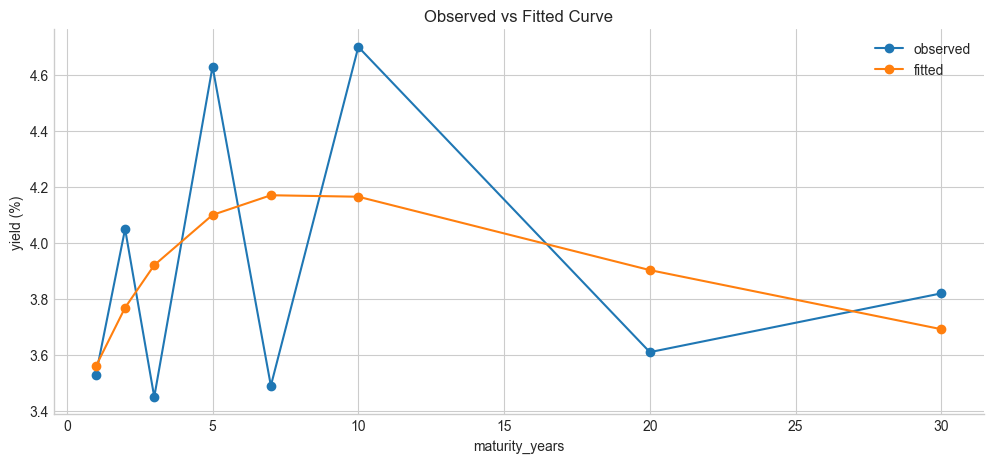

In [7]:
ax = fitted_df.reset_index().plot(x='maturity_years', y=['observed', 'fitted'], marker='o', title='Observed vs Fitted Curve')
ax.set_ylabel('yield (%)')
plt.show()


## Daily fitted-curve residual signal family

To create a third signal family alongside OU and PCA, we fit a Nelson-Siegel curve **each day** and store tenor-level residuals.

This lets us ask:

- which tenors are rich or cheap relative to the fitted curve today?
- are those residuals extreme relative to their own recent history?


In [8]:
from scipy.optimize import minimize

tenor_order = list(tenors.keys())
tenor_columns = [tenors[k][0] for k in tenor_order]
maturity_years = np.array([tenors[k][1] for k in tenor_order], dtype=float)

def fit_daily_curve(row: pd.Series):
    y = row[tenor_columns].to_numpy(dtype=float)
    guess = np.array([y[-1], -1.0, 1.0, 2.0], dtype=float)
    result = minimize(curve_objective, guess, args=(maturity_years, y), method='L-BFGS-B')
    params = result.x
    fitted = nelson_siegel_yield(maturity_years, *params)
    residual = y - fitted
    return params, fitted, residual, float(result.fun), bool(result.success)

fitted_rows = []
residual_rows = []
objective_rows = []

for dt, row in curve.iterrows():
    params, fitted, residual, objective, success = fit_daily_curve(row)
    fitted_rows.append(pd.Series(fitted, index=tenor_order, name=dt))
    residual_rows.append(pd.Series(residual, index=tenor_order, name=dt))
    objective_rows.append(pd.Series({'objective': objective, 'success': success}, name=dt))

fitted_curve_history = pd.DataFrame(fitted_rows)
residual_history = pd.DataFrame(residual_rows)
fit_diagnostics = pd.DataFrame(objective_rows)

residual_history.tail()


                  1Y        2Y        3Y        5Y        7Y       10Y       20Y       30Y
2026-02-18 -0.006186  0.008939  0.003365 -0.003114  0.000394 -0.027623  0.071173 -0.046966
2026-02-19 -0.005870  0.006974  0.006350 -0.005019  0.000410 -0.026914  0.071315 -0.047225
2026-02-20 -0.007221  0.010594  0.003644 -0.004184  0.001091 -0.029779  0.075448 -0.049580
2026-02-23 -0.003733  0.001463  0.008637 -0.001585  0.000003 -0.030587  0.074280 -0.048470
2026-02-25 -0.001375 -0.007397  0.019264 -0.009832  0.004853 -0.029791  0.070100 -0.045823

In [9]:
residual_zscores = (residual_history - residual_history.rolling(60).mean()) / residual_history.rolling(60).std()
latest_residual = residual_history.iloc[-1].rename('residual')
latest_residual_z = residual_zscores.iloc[-1].rename('zscore')
residual_snapshot = pd.concat([latest_residual, latest_residual_z], axis=1).sort_values('zscore')
residual_snapshot


     residual    zscore
20Y  0.070100 -1.840792
5Y  -0.009832 -1.027135
2Y  -0.007397 -0.946205
10Y -0.029791  0.546981
3Y   0.019264  0.830264
1Y  -0.001375  1.027474
30Y -0.045823  1.781172
7Y   0.004853  1.800741

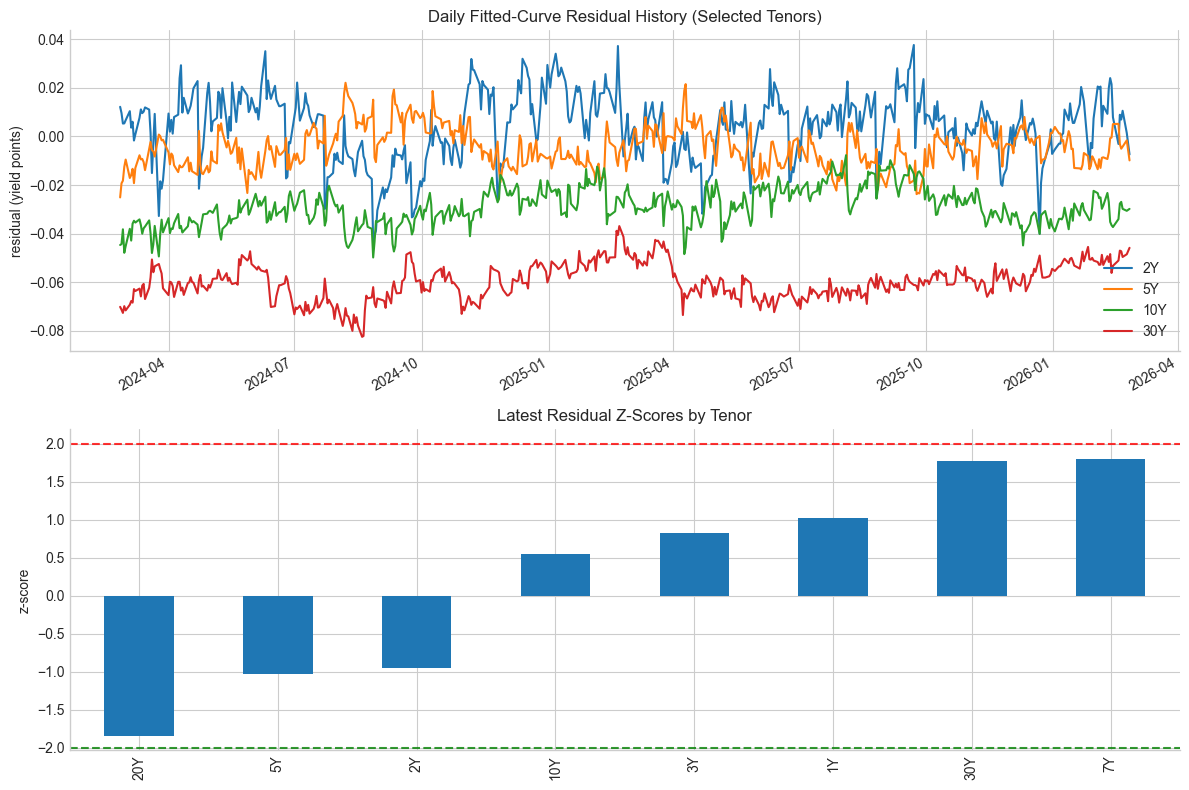

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=False)
residual_history[['2Y', '5Y', '10Y', '30Y']].plot(ax=axes[0], title='Daily Fitted-Curve Residual History (Selected Tenors)')
axes[0].set_ylabel('residual (yield points)')

latest_residual_z.sort_values().plot(kind='bar', ax=axes[1], title='Latest Residual Z-Scores by Tenor')
axes[1].axhline(2.0, color='red', linestyle='--', alpha=0.8)
axes[1].axhline(-2.0, color='green', linestyle='--', alpha=0.8)
axes[1].set_ylabel('z-score')
plt.tight_layout()
plt.show()


In [11]:
daily_signal = pd.DataFrame(index=residual_zscores.index)
for tenor in residual_zscores.columns:
    daily_signal[f'{tenor}_signal'] = np.where(residual_zscores[tenor] > 2.0, -1, np.where(residual_zscores[tenor] < -2.0, 1, 0))

signal_summary = pd.concat([
    residual_history.iloc[-1].rename('latest_residual'),
    residual_zscores.iloc[-1].rename('latest_zscore'),
    daily_signal.iloc[-1].rename('latest_signal'),
], axis=1)
signal_summary


            latest_residual  latest_zscore  latest_signal
1Y                -0.001375       1.027474            NaN
2Y                -0.007397      -0.946205            NaN
3Y                 0.019264       0.830264            NaN
5Y                -0.009832      -1.027135            NaN
7Y                 0.004853       1.800741            NaN
10Y               -0.029791       0.546981            NaN
20Y                0.070100      -1.840792            NaN
30Y               -0.045823       1.781172            NaN
1Y_signal               NaN            NaN            0.0
2Y_signal               NaN            NaN            0.0
3Y_signal               NaN            NaN            0.0
5Y_signal               NaN            NaN            0.0
7Y_signal               NaN            NaN            0.0
10Y_signal              NaN            NaN            0.0
20Y_signal              NaN            NaN            0.0
30Y_signal              NaN            NaN            0.0

## Interpretation and next steps

This notebook now contains two layers:

1. a single-day fitted curve view
2. a daily fitted-curve residual history and rolling z-score screen

That second layer is the new Chapter 8 signal family, complementary to:

- Chapter 2 scalar mean reversion on a spread
- Chapter 3 PCA residual dislocations
